# Pertemuan 5: Histogram, Histogram Equalization, dan Dithering

Nama: Sahrul Ramadhani  
NIM: 244107020058  
Kelas: TI 3C

## 1. Persiapan dan pembacaan citra

Materi menggunakan histogram grayscale dan histogram tiap channel warna, histogram equalization, CLAHE, kuantisasi warna, ordered dithering, dan error diffusion.

In [1]:
from pathlib import Path
import sys
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

SEARCH_DIRS = [
    Path.cwd() / 'Minggu 5' / 'images',
    Path.cwd() / 'images',
    Path.cwd() / 'Minggu 3' / 'images',
    Path('/content/drive/MyDrive/PCVK/Minggu 5/images'),
    Path('/content/drive/MyDrive/PCVK/Minggu 3/images'),
]

def find_image(filename):
    for folder in SEARCH_DIRS:
        candidate = folder / filename
        if candidate.is_file():
            return candidate
    searched = '\n'.join(str(folder / filename) for folder in SEARCH_DIRS)
    raise FileNotFoundError(f'File {filename} tidak ditemukan. Path yang diperiksa:\n{searched}')

def read_color(filename):
    path = find_image(filename)
    image = cv.imread(str(path), cv.IMREAD_COLOR)
    if image is None:
        raise ValueError(f'Citra tidak dapat dibaca: {path}')
    return path, image

image_path, image_bgr = read_color('peppers.jpg')
image_rgb = cv.cvtColor(image_bgr, cv.COLOR_BGR2RGB)
image_gray = cv.cvtColor(image_bgr, cv.COLOR_BGR2GRAY)
print('Citra:', image_path)
print('Shape warna:', image_bgr.shape)
print('Shape grayscale:', image_gray.shape)

Citra: D:\Pengolahan Citra dan Visi Komputer\Minggu 3\images\peppers.jpg
Shape warna: (348, 424, 3)
Shape grayscale: (348, 424)


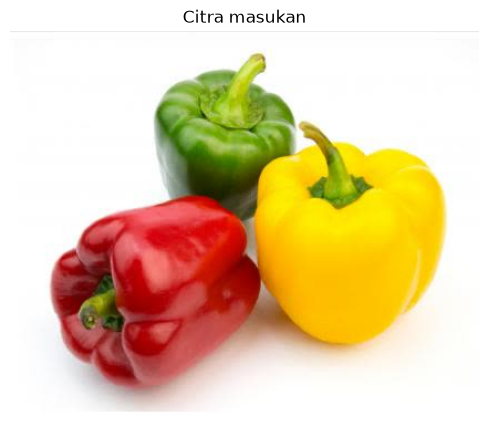

In [2]:
def show_bgr(image, title=''):
    plt.figure(figsize=(7, 5))
    plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
    plt.axis('off')
    if title:
        plt.title(title)
    plt.show()

def show_gray(image, title=''):
    plt.figure(figsize=(7, 5))
    plt.imshow(image, cmap='gray', vmin=0, vmax=255)
    plt.axis('off')
    if title:
        plt.title(title)
    plt.show()

show_bgr(image_bgr, 'Citra masukan')

## 2. Histogram citra grayscale

Histogram menghitung frekuensi setiap intensitas `j` dari `0` sampai `L-1`. Untuk citra 8-bit, `L = 256`.

Jumlah pixel: 147552
Jumlah histogram: 147552
Jumlah probabilitas: 1.0


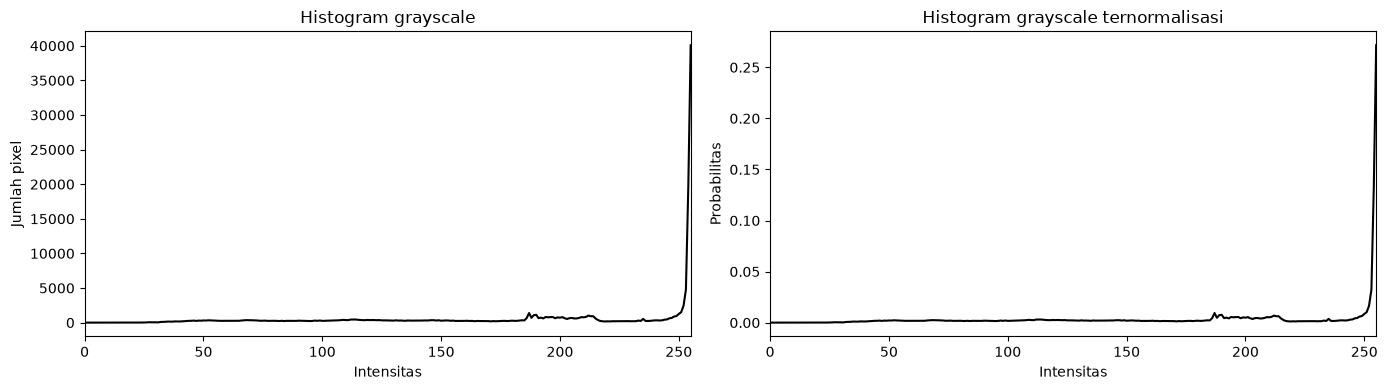

In [3]:
def histogram_manual(gray):
    gray_uint8 = np.asarray(gray, dtype=np.uint8)
    return np.bincount(gray_uint8.ravel(), minlength=256)

gray_hist = histogram_manual(image_gray)
gray_probability = gray_hist / image_gray.size
print('Jumlah pixel:', image_gray.size)
print('Jumlah histogram:', int(gray_hist.sum()))
print('Jumlah probabilitas:', gray_probability.sum())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(np.arange(256), gray_hist, color='black')
axes[0].set_title('Histogram grayscale')
axes[0].set_xlabel('Intensitas')
axes[0].set_ylabel('Jumlah pixel')
axes[0].set_xlim(0, 255)
axes[1].plot(np.arange(256), gray_probability, color='black')
axes[1].set_title('Histogram grayscale ternormalisasi')
axes[1].set_xlabel('Intensitas')
axes[1].set_ylabel('Probabilitas')
axes[1].set_xlim(0, 255)
plt.tight_layout()
plt.show()

### Pembacaan histogram

- Batang menumpuk di kiri: citra cenderung gelap.
- Batang menumpuk di kanan: citra cenderung terang.
- Rentang sempit: kontras rendah.
- Rentang lebar: kontras tinggi.
- Dua puncak: citra dapat memiliki dua kelompok objek dengan tingkat terang berbeda.
- Menumpuk di 0 atau 255: kemungkinan terjadi clipping.
- Histogram hanya menyimpan jumlah intensitas, bukan posisi pixel.

## 3. Histogram citra warna

Citra warna memiliki satu histogram untuk setiap channel. Histogram dihitung pada urutan RGB agar label channel sesuai tampilan.

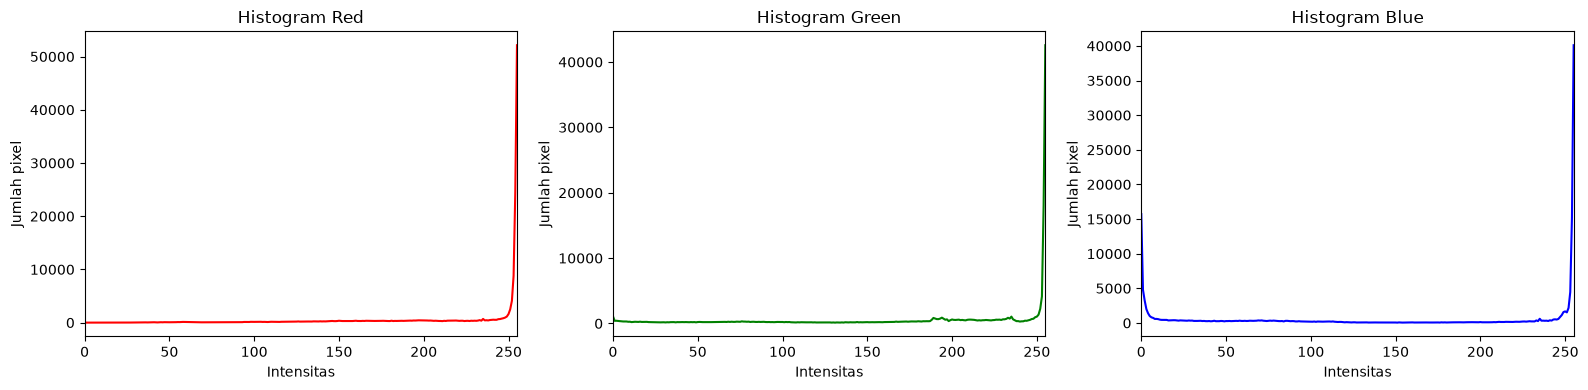

Jumlah pixel setiap channel: [147552, 147552, 147552]


In [4]:
channel_names = ('Red', 'Green', 'Blue')
channel_colors = ('red', 'green', 'blue')
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for index, (name, color) in enumerate(zip(channel_names, channel_colors)):
    channel_hist = histogram_manual(image_rgb[:, :, index])
    axes[index].plot(np.arange(256), channel_hist, color=color)
    axes[index].set_title(f'Histogram {name}')
    axes[index].set_xlabel('Intensitas')
    axes[index].set_ylabel('Jumlah pixel')
    axes[index].set_xlim(0, 255)
plt.tight_layout()
plt.show()
print('Jumlah pixel setiap channel:', [int(histogram_manual(image_rgb[:, :, i]).sum()) for i in range(3)])

## 4. Histogram equalization manual

Rumus pemetaan materi:

```text
s = (L - 1) × CDF(r)
```

Urutannya adalah histogram, normalisasi, CDF, skala, pembulatan, lalu pemetaan pixel.

Nilai mapping 0, 64, 128, 192, 255: [  0  14  49  86 255]
Rentang awal: 13 sampai 255
Rentang hasil: 0 sampai 255


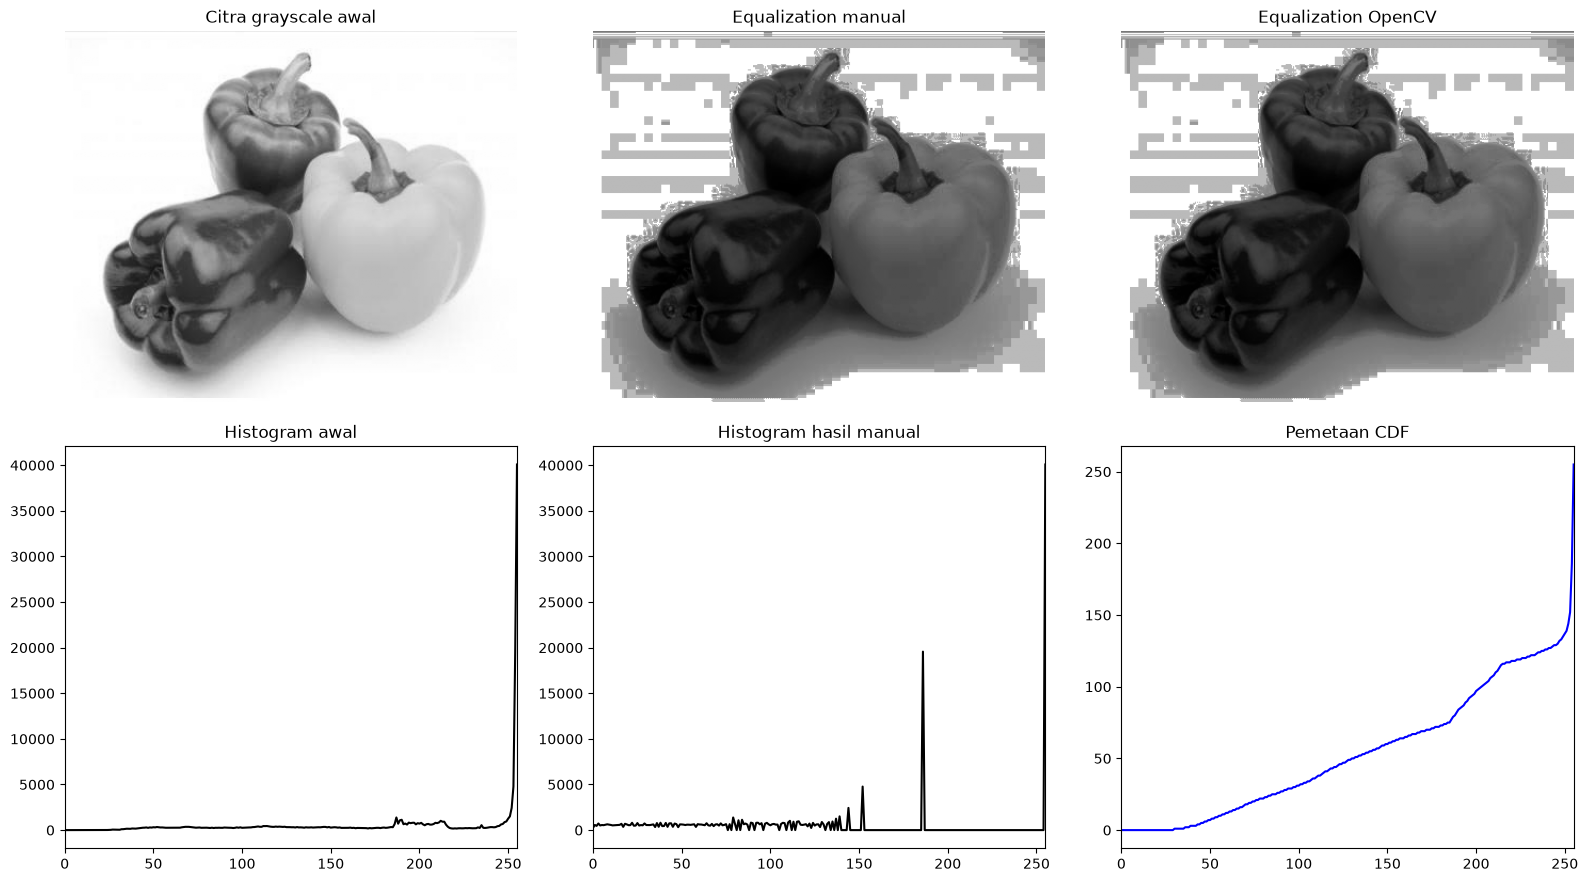

In [5]:
def equalize_histogram_manual(gray):
    gray_uint8 = np.asarray(gray, dtype=np.uint8)
    histogram = histogram_manual(gray_uint8)
    probability = histogram / gray_uint8.size
    cdf = np.cumsum(probability)
    mapping = np.rint(255 * cdf).clip(0, 255).astype(np.uint8)
    equalized = mapping[gray_uint8]
    return equalized, histogram, probability, cdf, mapping

equalized_manual, equalization_hist, equalization_probability, equalization_cdf, equalization_mapping = equalize_histogram_manual(image_gray)
equalized_opencv = cv.equalizeHist(image_gray)
print('Nilai mapping 0, 64, 128, 192, 255:', equalization_mapping[[0, 64, 128, 192, 255]])
print('Rentang awal:', int(image_gray.min()), 'sampai', int(image_gray.max()))
print('Rentang hasil:', int(equalized_manual.min()), 'sampai', int(equalized_manual.max()))

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes[0, 0].imshow(image_gray, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Citra grayscale awal')
axes[0, 1].imshow(equalized_manual, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title('Equalization manual')
axes[0, 2].imshow(equalized_opencv, cmap='gray', vmin=0, vmax=255)
axes[0, 2].set_title('Equalization OpenCV')
axes[1, 0].plot(gray_hist, color='black')
axes[1, 0].set_title('Histogram awal')
axes[1, 1].plot(histogram_manual(equalized_manual), color='black')
axes[1, 1].set_title('Histogram hasil manual')
axes[1, 2].plot(equalization_mapping, color='blue')
axes[1, 2].set_title('Pemetaan CDF')
for ax in axes[0, :]:
    ax.axis('off')
for ax in axes[1, :]:
    ax.set_xlim(0, 255)
plt.tight_layout()
plt.show()

Histogram equalization memakai statistik citra itu sendiri. Hasilnya meningkatkan sebaran intensitas, tetapi histogram digital tidak harus benar-benar rata. Beberapa intensitas lama dapat dipetakan ke intensitas baru yang sama, sehingga celah histogram dapat muncul.

### Contoh hitung 4×4 dari materi

Contoh berikut memakai 9 level keabuan. Frekuensinya adalah 6 pixel bernilai 2, 5 pixel bernilai 3, 4 pixel bernilai 4, dan 1 pixel bernilai 5.

In [6]:
example_4x4 = np.array([
    [2, 3, 3, 2],
    [4, 2, 4, 3],
    [3, 2, 3, 5],
    [2, 4, 2, 4],
], dtype=np.uint8)
example_hist = np.bincount(example_4x4.ravel(), minlength=9)
example_probability = example_hist / example_4x4.size
example_cdf = np.cumsum(example_probability)
example_mapping = np.rint(8 * example_cdf).astype(np.uint8)
example_equalized = example_mapping[example_4x4]
print('Histogram:', example_hist.tolist())
print('Probabilitas:', example_probability.tolist())
print('CDF:', example_cdf.tolist())
print('Pemetaan level 0 sampai 8:', example_mapping.tolist())
print('Pemetaan penting: 2 ->', int(example_mapping[2]), ', 3 ->', int(example_mapping[3]), ', 4 ->', int(example_mapping[4]), ', 5 ->', int(example_mapping[5]))
print('Citra hasil:\n', example_equalized)

Histogram: [0, 0, 6, 5, 4, 1, 0, 0, 0]
Probabilitas: [0.0, 0.0, 0.375, 0.3125, 0.25, 0.0625, 0.0, 0.0, 0.0]
CDF: [0.0, 0.0, 0.375, 0.6875, 0.9375, 1.0, 1.0, 1.0, 1.0]
Pemetaan level 0 sampai 8: [0, 0, 3, 6, 8, 8, 8, 8, 8]
Pemetaan penting: 2 -> 3 , 3 -> 6 , 4 -> 8 , 5 -> 8
Citra hasil:
 [[3 6 6 3]
 [8 3 8 6]
 [6 3 6 8]
 [3 8 3 8]]


## 5. CLAHE dan equalization citra warna

Equalisasi RGB satu per satu dapat mengubah hubungan antar-channel dan membuat warna bergeser. Untuk citra warna, equalization diterapkan pada kanal terang saja. Di sini digunakan kanal `Y` pada ruang warna YCrCb.

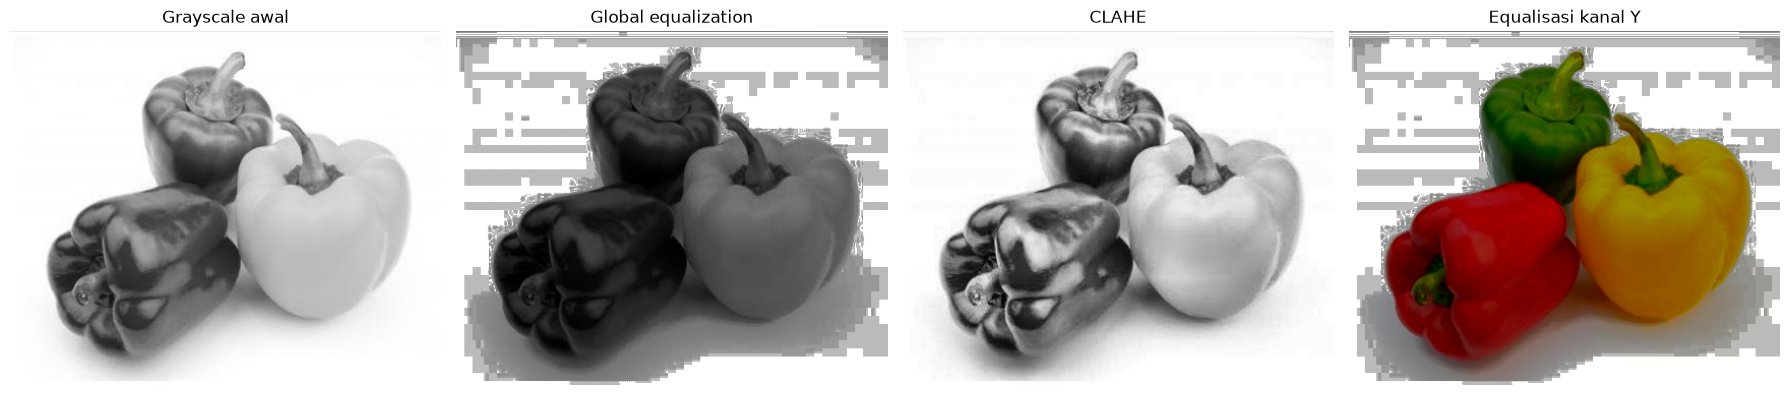

In [7]:
clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
clahe_gray = clahe.apply(image_gray)

ycrcb = cv.cvtColor(image_bgr, cv.COLOR_BGR2YCrCb)
ycrcb_equalized = ycrcb.copy()
ycrcb_equalized[:, :, 0] = cv.equalizeHist(ycrcb[:, :, 0])
color_equalized = cv.cvtColor(ycrcb_equalized, cv.COLOR_YCrCb2BGR)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(image_gray, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Grayscale awal')
axes[1].imshow(equalized_manual, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Global equalization')
axes[2].imshow(clahe_gray, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('CLAHE')
axes[3].imshow(cv.cvtColor(color_equalized, cv.COLOR_BGR2RGB))
axes[3].set_title('Equalisasi kanal Y')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

CLAHE membagi citra menjadi petak kecil, melakukan equalization pada tiap petak, membatasi penguatan histogram dengan `clipLimit`, lalu menghaluskan batas petak dengan interpolasi. CLAHE membantu saat equalization global membuat noise atau area backlight terlalu kuat.

## 6. Kuantisasi warna dan nearest-color

Kuantisasi memangkas jumlah warna. Pada 8-bit grayscale tersedia 256 level, sedangkan 4-bit memiliki 16 level, 2-bit memiliki 4 level, dan 1-bit memiliki 2 level.

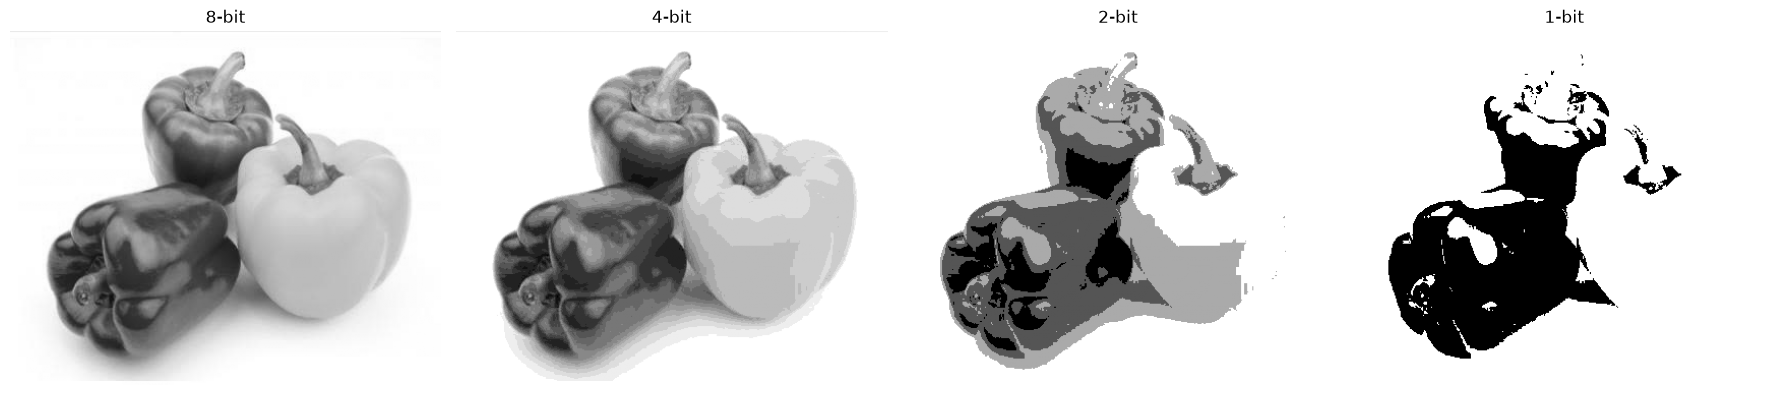

In [8]:
def quantize_gray(gray, bits):
    levels = 2 ** bits
    step = 256 / levels
    quantized_index = np.floor(np.asarray(gray, dtype=np.float32) / step).clip(0, levels - 1)
    quantized = np.rint(quantized_index * (255 / (levels - 1))).astype(np.uint8)
    return quantized

gray_quantized = [quantize_gray(image_gray, bits) for bits in (8, 4, 2, 1)]
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, bits, result in zip(axes, (8, 4, 2, 1), gray_quantized):
    ax.imshow(result, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'{bits}-bit')
    ax.axis('off')
plt.tight_layout()
plt.show()

### Penyederhanaan citra RGB menjadi 8 warna

Delapan warna yang dipakai adalah hitam, merah, hijau, kuning, biru, cyan, magenta, dan putih. Setiap channel RGB dibulatkan ke 0 atau 255.

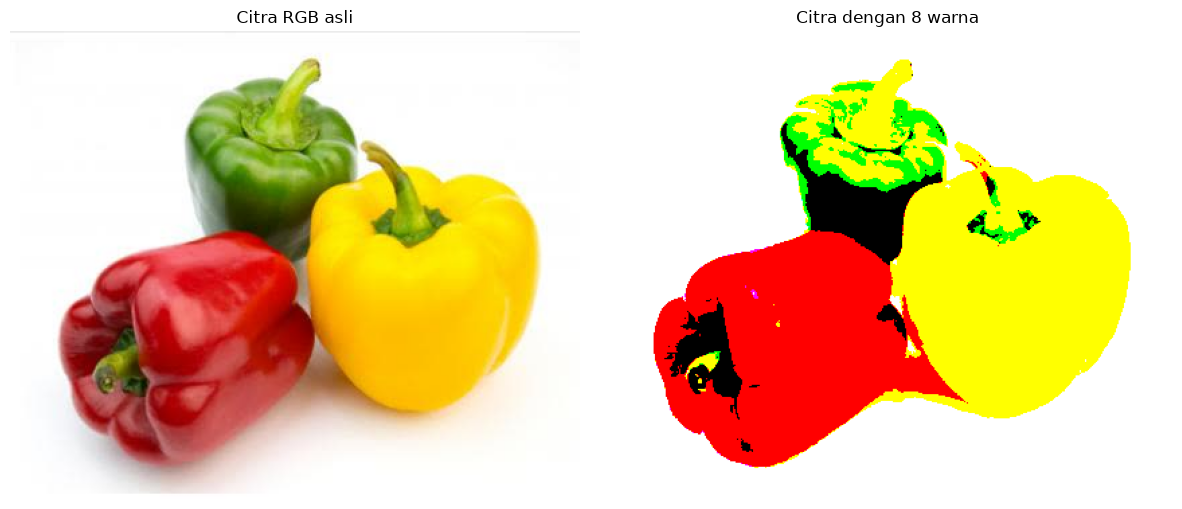

Warna unik hasil: 7


In [9]:
def quantize_rgb_8colors(rgb):
    return np.where(np.asarray(rgb, dtype=np.uint8) >= 128, 255, 0).astype(np.uint8)

rgb_8colors = quantize_rgb_8colors(image_rgb)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title('Citra RGB asli')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(rgb_8colors)
plt.title('Citra dengan 8 warna')
plt.axis('off')
plt.tight_layout()
plt.show()
print('Warna unik hasil:', len(np.unique(rgb_8colors.reshape(-1, 3), axis=0)))

## 7. Dithering tanpa error diffusion

Tiga cara pada materi:

- Warna terdekat: setiap pixel langsung diganti warna palet terdekat.
- Ordered dithering: pixel dibandingkan dengan matriks ambang Bayer.
- Error diffusion: error pembulatan disebarkan ke tetangga yang belum diproses.

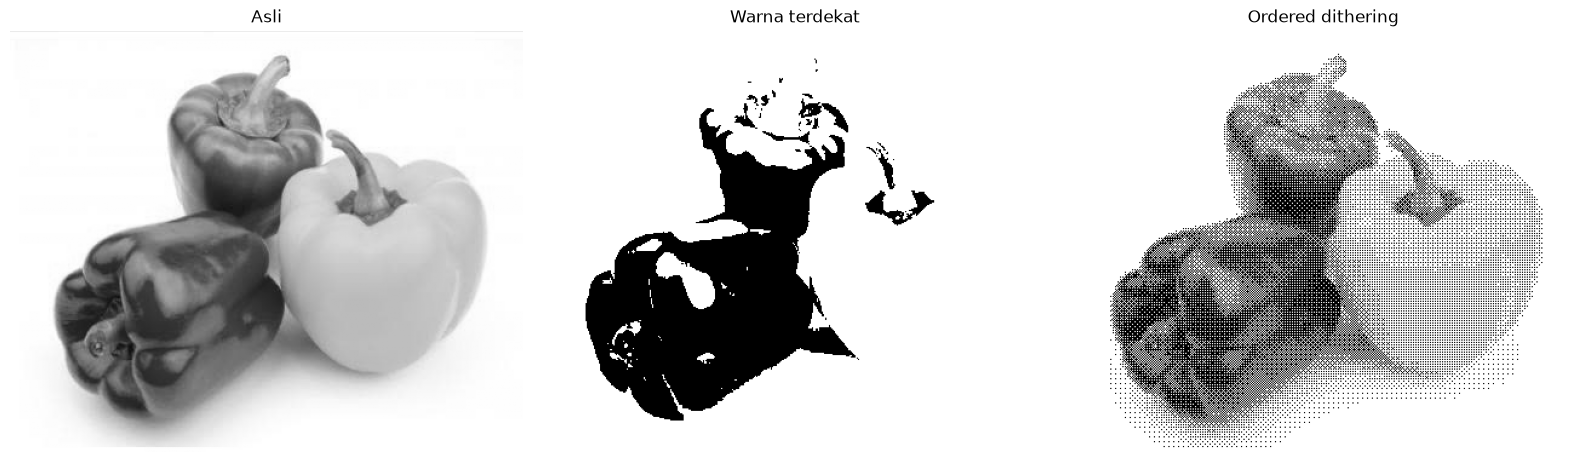

In [10]:
def nearest_binary(gray):
    gray_float = np.asarray(gray, dtype=np.float32)
    return np.where(gray_float >= 128, 255, 0).astype(np.uint8)

def ordered_dither(gray):
    gray_float = np.asarray(gray, dtype=np.float32)
    bayer4 = np.array([
        [0, 8, 2, 10],
        [12, 4, 14, 6],
        [3, 11, 1, 9],
        [15, 7, 13, 5],
    ], dtype=np.float32)
    threshold = (bayer4 + 0.5) * (255 / 16)
    tiled = np.tile(threshold, (int(np.ceil(gray.shape[0] / 4)), int(np.ceil(gray.shape[1] / 4))))
    tiled = tiled[:gray.shape[0], :gray.shape[1]]
    return np.where(gray_float > tiled, 255, 0).astype(np.uint8)

nearest_result = nearest_binary(image_gray)
ordered_result = ordered_dither(image_gray)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, result, title in zip(axes, (image_gray, nearest_result, ordered_result), ('Asli', 'Warna terdekat', 'Ordered dithering')):
    ax.imshow(result, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 8. Error diffusion Floyd–Steinberg

Pemindaian dilakukan dari kiri ke kanan dan dari atas ke bawah.

```text
error = nilai_asli - warna_terdekat
kanan       += 7/16 × error
bawah_kiri  += 3/16 × error
bawah       += 5/16 × error
bawah_kanan += 1/16 × error
```

Jumlah bobot adalah `7/16 + 3/16 + 5/16 + 1/16 = 1`. Error hanya dikirim ke pixel yang belum diproses. Array kerja memakai float dan nilainya dipotong ke rentang 0–255.

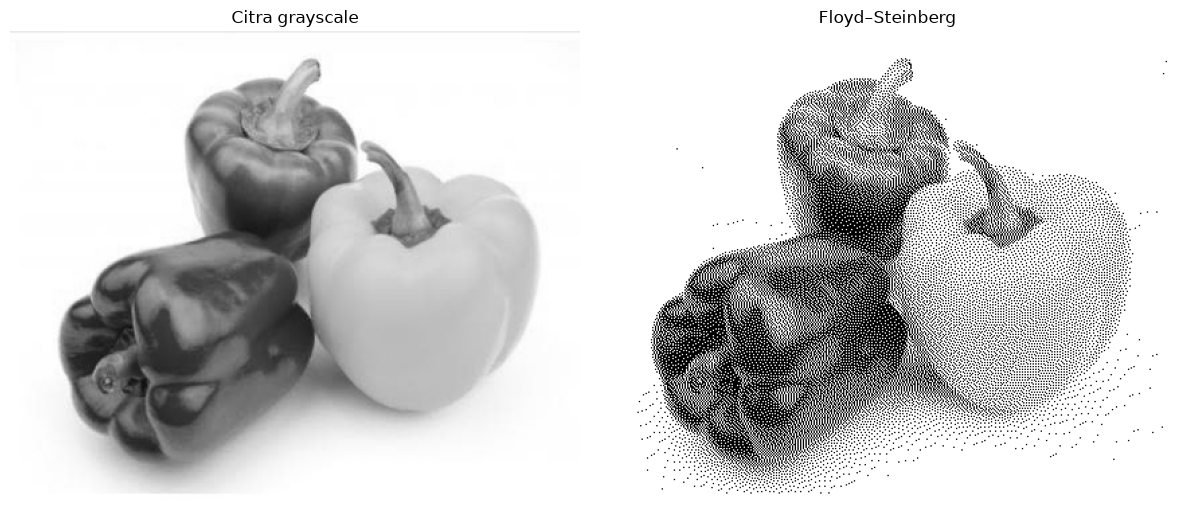

In [11]:
def floyd_steinberg(gray):
    work = np.asarray(gray, dtype=np.float32).copy()
    height, width = work.shape
    output = np.zeros((height, width), dtype=np.uint8)
    for y in range(height):
        for x in range(width):
            old_value = work[y, x]
            new_value = 255.0 if old_value >= 128.0 else 0.0
            output[y, x] = np.uint8(new_value)
            error = old_value - new_value
            if x + 1 < width:
                work[y, x + 1] += (7 / 16) * error
            if y + 1 < height and x > 0:
                work[y + 1, x - 1] += (3 / 16) * error
            if y + 1 < height:
                work[y + 1, x] += (5 / 16) * error
            if y + 1 < height and x + 1 < width:
                work[y + 1, x + 1] += (1 / 16) * error
            if x + 1 < width:
                work[y, x + 1] = np.clip(work[y, x + 1], 0, 255)
            if y + 1 < height:
                work[y + 1, max(0, x - 1):min(width, x + 2)] = np.clip(
                    work[y + 1, max(0, x - 1):min(width, x + 2)], 0, 255
                )
    return output

floyd_result = floyd_steinberg(image_gray)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(image_gray, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Citra grayscale')
axes[1].imshow(floyd_result, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Floyd–Steinberg')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

## 9. Dithering berwarna dengan Floyd–Steinberg

Untuk citra warna, error diproses terpisah pada channel R, G, dan B.

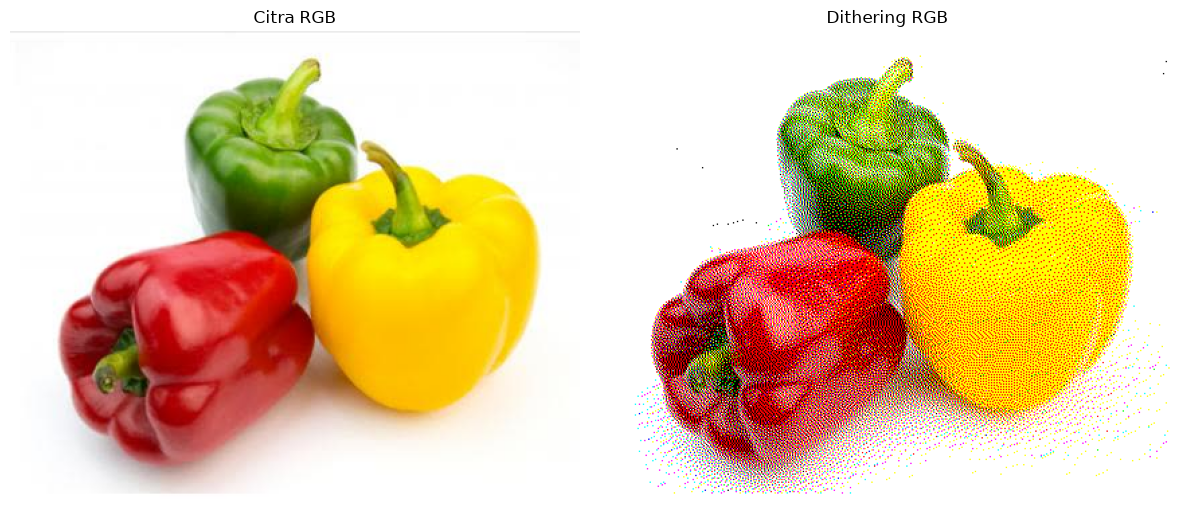

In [12]:
def floyd_steinberg_color(rgb):
    channels = [floyd_steinberg(rgb[:, :, channel]) for channel in range(3)]
    return np.stack(channels, axis=2)

color_dither = floyd_steinberg_color(image_rgb)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(image_rgb)
axes[0].set_title('Citra RGB')
axes[1].imshow(color_dither)
axes[1].set_title('Dithering RGB')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

### Contoh pembagian error satu pixel

Jika pixel bernilai 130 dan palet hanya 0 serta 255, warna terdekat adalah 255. Error adalah `130 - 255 = -125`. Pembagiannya:

- kanan: `7/16 × -125 = -54,7`;
- bawah kiri: `3/16 × -125 = -23,4`;
- bawah: `5/16 × -125 = -39,1`;
- bawah kanan: `1/16 × -125 = -7,8`.

Jumlah pembagian kembali menjadi -125.

### Kesalahan yang harus dihindari

- Konvensi sumbu tertukar: pada fungsi ini `x` adalah kolom dan `y` adalah baris.
- Error diproses dengan tipe integer sehingga pecahan terpotong.
- Nilai tetangga dibiarkan kurang dari 0 atau lebih dari 255.
- Tetangga di luar batas citra tetap diakses.
- Dithering diterapkan sebelum kuantisasi dasar selesai.
- Error channel RGB dicampur; setiap channel diproses terpisah.
- Bobot Floyd–Steinberg tidak berjumlah 1.

Perbandingan metode:

- Thresholding memakai satu ambang tetap, sehingga gradasi hilang.
- Ordered dithering memakai pola ambang Bayer, cepat tetapi pola kotak dapat terlihat.
- Floyd–Steinberg menyebarkan error, sehingga gradasi terlihat lebih halus dan teks lebih mudah terbaca.

## 10. Kesimpulan

- Histogram membaca sebaran intensitas, tetapi tidak menyimpan posisi pixel.
- Histogram ternormalisasi memakai peluang dan jumlah seluruh peluang sama dengan 1.
- Histogram equalization memakai CDF untuk memetakan intensitas lama ke intensitas baru.
- Equalization global dapat menaikkan kontras, tetapi dapat ikut menguatkan noise.
- CLAHE bekerja pada petak lokal dan membatasi penguatan histogram.
- Equalisasi kanal terang pada YCrCb menjaga warna lebih baik daripada equalizing R, G, dan B secara terpisah.
- Kuantisasi mengurangi jumlah warna dan dapat menimbulkan banding.
- Nearest-color langsung membulatkan pixel.
- Ordered dithering memakai pola ambang Bayer.
- Floyd–Steinberg menyebarkan error ke kanan, bawah kiri, bawah, dan bawah kanan dengan bobot 7/16, 3/16, 5/16, dan 1/16.
- Error diffusion adalah area operation karena satu pixel memengaruhi pixel tetangganya.